# Studio sulla Normalizzazione dello Scheletro

Questo notebook presenta uno studio rigoroso sull'utilità della normalizzazione dello scheletro per l'analisi del movimento umano. La normalizzazione è una tecnica fondamentale per rendere i dati di pose invarianti rispetto a fattori estrinseci come la distanza dalla camera e le dimensioni fisiche dei soggetti.

## Obiettivi dello Studio

1. **Analizzare la variabilità** inter-soggetto dovuta a differenze antropometriche
2. **Valutare l'efficacia** della normalizzazione basata sulla distanza inter-spalla
3. **Confrontare distribuzioni** di lunghezze ossee prima e dopo la normalizzazione
4. **Quantificare** la riduzione della varianza attraverso metriche statistiche
5. **Visualizzare** gli effetti della normalizzazione su campioni reali

## 1. Setup e Import

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from sklearn.metrics import silhouette_score
import warnings
import numpy as np
from sklearn.decomposition import PCA
from hdbscan import HDBSCAN

from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals


warnings.filterwarnings('ignore')

# Import della classe SkeletonPATS
import sys
sys.path.append('/home/paolo/Projects/Posemi/dataset/src')
from utils.skeletonPATS import SkeletonPATS

# Configurazione visualizzazioni
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Setup completato!")

Setup completato!


## 2. Caricamento Dati

Carichiamo i dati di pose dal dataset processato. Ogni sample contiene sequenze temporali di keypoints 2D estratti da video di gesture.

In [12]:
# Carica tutti gli intervalli disponibili
speaker = "fallon"
split = "dev"

intervals = get_speaker_intervals(speaker, split=split)
print(f"Numero totale di dataset disponibili: {len(intervals)}")

# Per test rapido, usa un subset. Per analisi completa, usa tutti
# N_DATASETS = 20  # subset per test veloce
N_DATASETS = len(intervals)  # tutti i dataset

print(f"Useremo {N_DATASETS} dataset per l'analisi")

Numero totale di dataset disponibili: 202
Useremo 202 dataset per l'analisi


## 3. Fondamenti Teorici della Normalizzazione

### 3.1 Problema della Variabilità

I dati di pose 2D estratti da video presentano variabilità dovuta a:

1. **Distanza dalla camera**: Un soggetto più lontano produce coordinate più piccole
2. **Dimensioni antropometriche**: Persone di statura diversa hanno scheletri di dimensioni diverse
3. **Risoluzione e calibrazione**: Diversi setup di acquisizione producono scale diverse

### 3.2 Metodo di Normalizzazione

La normalizzazione basata sulla **distanza inter-spalla** è definita come:

$$
\mathbf{p}_{norm} = \frac{\mathbf{p}}{d_{shoulder}} \cdot s
$$

dove:
- $\mathbf{p}$ sono le coordinate originali
- $d_{shoulder} = ||\mathbf{p}_{LShoulder} - \mathbf{p}_{RShoulder}||_2$ è la distanza euclidea tra le spalle
- $s$ è un fattore di scala opzionale (default 1.0)

### 3.3 Vantaggi Attesi

1. **Invarianza alla scala**: Gli scheletri normalizzati hanno proporzioni confrontabili
2. **Riduzione varianza**: La variabilità inter-campione dovrebbe diminuire significativamente
3. **Migliore generalizzazione**: I modelli ML possono imparare pattern geometrici intrinseci

## 4. Analisi delle Lunghezze Ossee

Analizziamo la distribuzione delle lunghezze ossee prima e dopo la normalizzazione. Le ossa rappresentano le distanze euclidee tra joint connessi nella gerarchia scheletrica.

Calcoleremo per ogni dataset:
- **Lunghezze ossee originali**: distanze tra joint nelle coordinate pixel originali
- **Lunghezze ossee normalizzate**: dopo normalizzazione sulla distanza inter-spalla
- **Metriche statistiche**: media, deviazione standard, coefficiente di variazione (CV)

In [13]:
from tqdm import tqdm

def compute_bone_statistics(poses: np.ndarray, normalized: bool = False, scale: float = 1.0):
    """
    Calcola statistiche sulle lunghezze ossee per un set di pose.
    
    Args:
        poses: Array di pose (T, J, 2)
        normalized: Se True, normalizza le pose prima del calcolo
        scale: Fattore di scala per la normalizzazione
    
    Returns:
        Dictionary con medie, std, CV per ogni osso
    """
    if normalized:
        poses = SkeletonPATS.normalize_skeleton(poses, scale=scale)
    
    # Calcola lunghezze ossee per ogni frame
    bone_lengths = SkeletonPATS.compute_bone_lengths(poses)  # (T, J)
    
    # Calcola statistiche per ogni joint
    bone_means = np.mean(bone_lengths, axis=0)
    bone_stds = np.std(bone_lengths, axis=0)
    bone_cvs = bone_stds / (bone_means + 1e-8)  # Coefficiente di variazione
    
    return {
        'means': bone_means,
        'stds': bone_stds,
        'cvs': bone_cvs,
        'all_data': bone_lengths
    }


In [14]:
# Calcola statistiche su tutti i dataset
results = []

for idx in tqdm(range(N_DATASETS), desc="Analisi dataset"):
    try:
        # Carica dataset
        clips = load_multiple_samples(
            speaker=speaker, 
            interval_ids=intervals[idx:idx+1]
        )
        
        # Estrai pose
        skeleton_poses = []
        for clip in clips:
            pose = clip['pose']
            pose[:, 0] = [0.0, 0.0]  # centra sul collo 
            skeleton_poses.append(pose)
        
        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        
        # Salta dataset troppo piccoli
        if len(skeleton_poses) < 10:
            continue
        
        # Calcola statistiche per originali
        stats_orig = compute_bone_statistics(skeleton_poses, normalized=False)
        
        # Calcola statistiche per normalizzati
        stats_norm = compute_bone_statistics(skeleton_poses, normalized=True, scale=1.0)
        
        # Joint di interesse (spalle, gomiti, polsi)
        joints_of_interest = [1, 2, 3, 4, 5, 6]  # RShoulder, RElbow, RWrist, LShoulder, LElbow, LWrist
        
        for joint_idx in joints_of_interest:
            results.append({
                'dataset_idx': idx,
                'joint_idx': joint_idx,
                'n_frames': len(skeleton_poses),
                # Statistiche originali
                'orig_mean': stats_orig['means'][joint_idx],
                'orig_std': stats_orig['stds'][joint_idx],
                'orig_cv': stats_orig['cvs'][joint_idx],
                # Statistiche normalizzate
                'norm_mean': stats_norm['means'][joint_idx],
                'norm_std': stats_norm['stds'][joint_idx],
                'norm_cv': stats_norm['cvs'][joint_idx],
            })
    
    except Exception as e:
        print(f"Errore nel dataset {idx}: {e}")
        continue

# Converti in DataFrame
df_results = pd.DataFrame(results)
print(f"\nDataset analizzati con successo: {df_results['dataset_idx'].nunique()}")
print(f"Totale misurazioni (dataset x joint): {len(df_results)}")
print(f"\nPrime righe dei risultati:")
print(df_results.head())

Analisi dataset: 100%|██████████| 202/202 [01:27<00:00,  2.31it/s]


Dataset analizzati con successo: 202
Totale misurazioni (dataset × joint): 1212

Prime righe dei risultati:
   dataset_idx  joint_idx  n_frames   orig_mean   orig_std   orig_cv  \
0            0          1       735  135.796404   8.838489  0.065086   
1            0          2       735  208.807031  19.868094  0.095151   
2            0          3       735  156.829939  48.028459  0.306245   
3            0          4       735  136.157475   8.854722  0.065033   
4            0          5       735  212.733349  12.908610  0.060680   

   norm_mean  norm_std   norm_cv  
0   0.499396  0.007940  0.015900  
1   0.768933  0.066639  0.086664  
2   0.576706  0.173547  0.300927  
3   0.500727  0.007935  0.015846  
4   0.785014  0.064042  0.081581  


## 5. Analisi delle Differenze (Paired Comparison)

Calcoliamo le differenze per ogni metrica tra originale e normalizzato:

$$\Delta_i = \text{metric}_{\text{norm}}(D_i) - \text{metric}_{\text{orig}}(D_i)$$

**Per deviazione standard e CV**: valori più bassi = meglio → $\Delta < 0$ significa normalizzazione efficace  
**Per invarianza**: $\Delta \approx 0$ significa che i rapporti anatomici sono preservati

In [15]:
# Calcola differenze per ogni metrica
# Per std e CV: valori più bassi = meglio → Delta < 0 significa normalizzazione migliore

df_results['delta_mean'] = df_results['norm_mean'] - df_results['orig_mean']
df_results['delta_std'] = df_results['norm_std'] - df_results['orig_std']
df_results['delta_cv'] = df_results['norm_cv'] - df_results['orig_cv']

# Aggiungi nomi dei joint per leggibilità
joint_names_map = {
    1: 'RShoulder',
    2: 'RElbow', 
    3: 'RWrist',
    4: 'LShoulder',
    5: 'LElbow',
    6: 'LWrist'
}
df_results['joint_name'] = df_results['joint_idx'].map(joint_names_map)

print("Statistiche descrittive delle differenze:\n")
delta_cols = [col for col in df_results.columns if col.startswith('delta_')]
print(df_results[delta_cols].describe())

print("\n\nDifferenze medie per joint:")
print(df_results.groupby('joint_name')[delta_cols].mean())

Statistiche descrittive delle differenze:

        delta_mean    delta_std     delta_cv
count  1212.000000  1212.000000  1212.000000
mean   -162.945441   -19.172037    -0.006352
std      36.398616    14.642041     0.038713
min    -311.168424   -65.042093    -0.247389
25%    -196.370840   -29.268903    -0.025349
50%    -152.872794   -13.822625    -0.003971
75%    -136.506976    -7.702938     0.008656
max     -51.281111    -0.733489     0.392154


Differenze medie per joint:
            delta_mean  delta_std  delta_cv
joint_name                                 
LElbow     -204.602295 -13.180039  0.009091
LShoulder  -138.540752  -6.927183 -0.035497
LWrist     -155.544107 -35.997212  0.016683
RElbow     -204.789593 -15.718235 -0.000557
RShoulder  -137.451832  -7.024881 -0.036566
RWrist     -136.744064 -36.184673  0.008731


## 6. Visualizzazione Confronto: Originale vs Normalizzato

Confrontiamo visivamente le distribuzioni delle metriche chiave (deviazione standard e coefficiente di variazione) prima e dopo la normalizzazione per ogni joint.

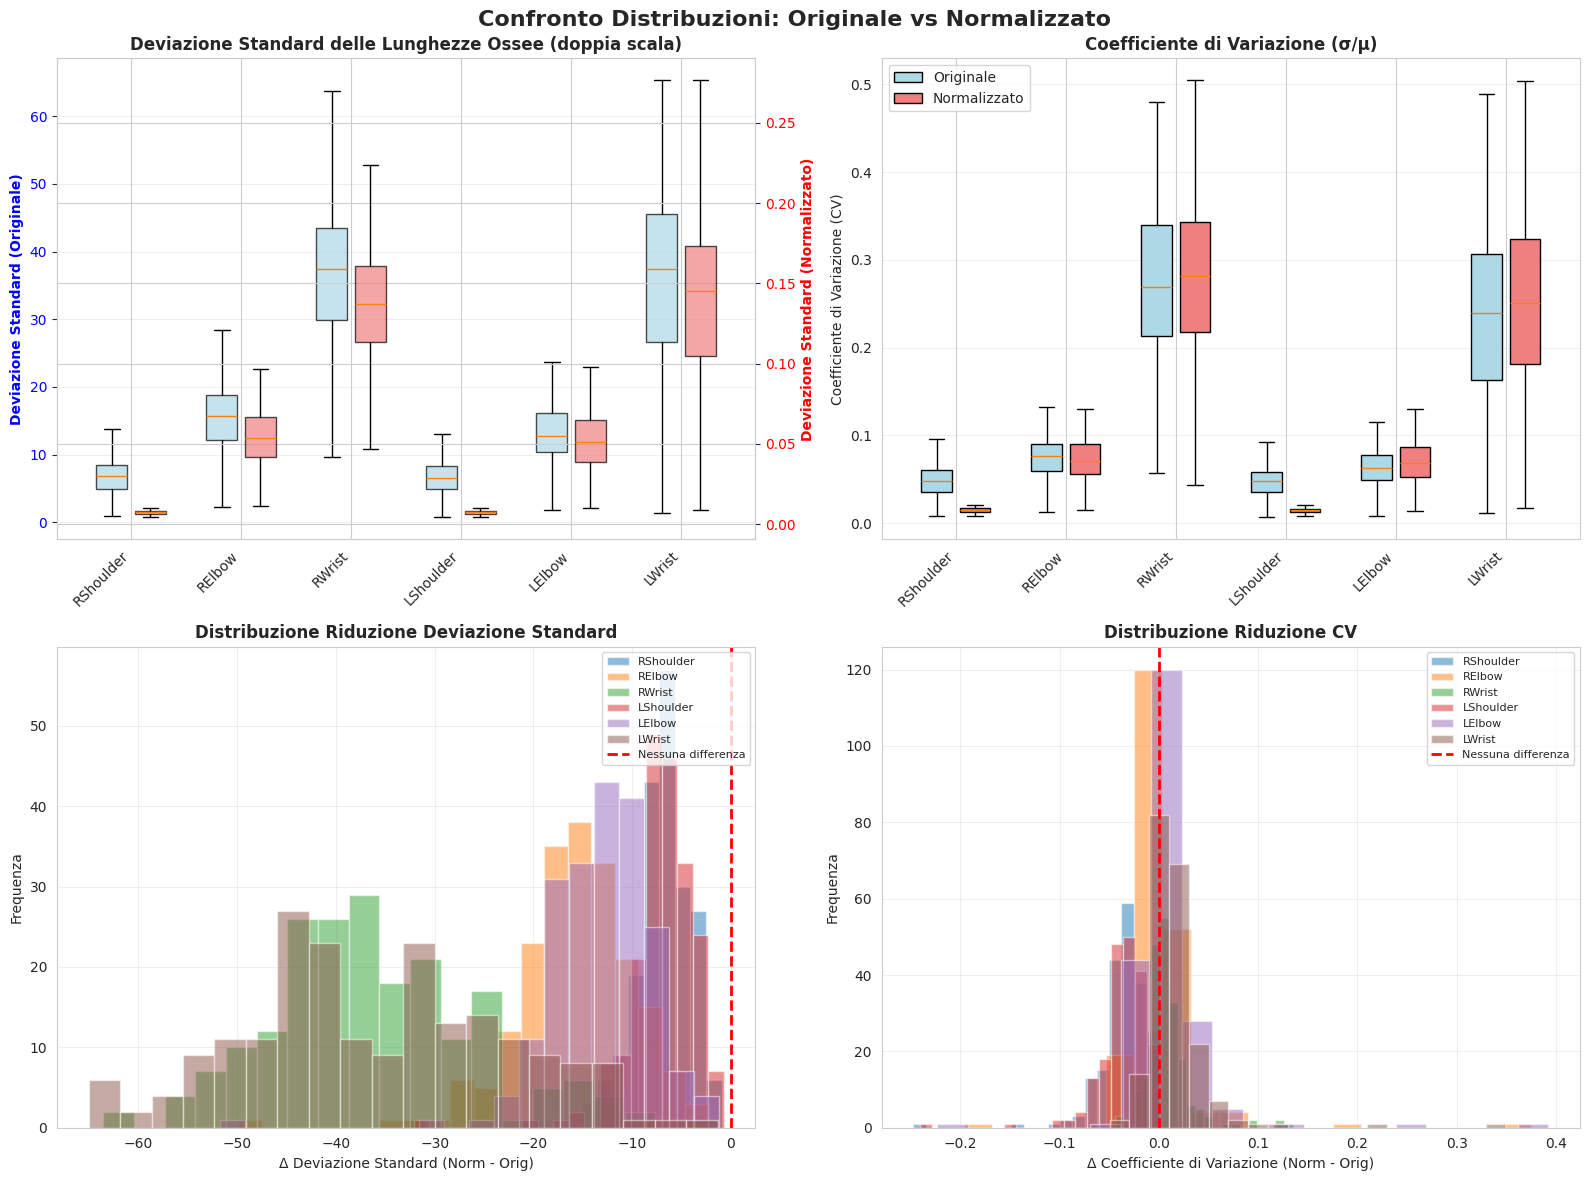


📊 STATISTICHE RIASSUNTIVE:

RShoulder:
  Δ Std medio: -7.0249 (100.0% dataset migliorati)
  Δ CV medio:  -0.0366 (100.0% dataset migliorati)

RElbow:
  Δ Std medio: -15.7182 (100.0% dataset migliorati)
  Δ CV medio:  -0.0006 (55.0% dataset migliorati)

RWrist:
  Δ Std medio: -36.1847 (100.0% dataset migliorati)
  Δ CV medio:  0.0087 (34.2% dataset migliorati)

LShoulder:
  Δ Std medio: -6.9272 (100.0% dataset migliorati)
  Δ CV medio:  -0.0355 (99.0% dataset migliorati)

LElbow:
  Δ Std medio: -13.1800 (100.0% dataset migliorati)
  Δ CV medio:  0.0091 (39.1% dataset migliorati)

LWrist:
  Δ Std medio: -35.9972 (100.0% dataset migliorati)
  Δ CV medio:  0.0167 (19.8% dataset migliorati)


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confronto Distribuzioni: Originale vs Normalizzato', fontsize=16, fontweight='bold')

# 1. Deviazione Standard per Joint (con doppia scala Y)
ax = axes[0, 0]
joint_order = ['RShoulder', 'RElbow', 'RWrist', 'LShoulder', 'LElbow', 'LWrist']
positions = np.arange(len(joint_order))
width = 0.35

# Crea secondo asse y
ax2 = ax.twinx()

for i, joint in enumerate(joint_order):
    joint_data = df_results[df_results['joint_name'] == joint]
    orig_std = joint_data['orig_std'].values
    norm_std = joint_data['norm_std'].values
    
    # Plot originale sull'asse sinistro
    bp1 = ax.boxplot([orig_std], positions=[i - width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    bp1['boxes'][0].set_facecolor('lightblue')
    bp1['boxes'][0].set_alpha(0.7)
    
    # Plot normalizzato sull'asse destro
    bp2 = ax2.boxplot([norm_std], positions=[i + width/2], widths=width*0.8,
                       patch_artist=True, showfliers=False)
    bp2['boxes'][0].set_facecolor('lightcoral')
    bp2['boxes'][0].set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(joint_order, rotation=45, ha='right')
ax.set_ylabel('Deviazione Standard (Originale)', color='blue', fontweight='bold')
ax2.set_ylabel('Deviazione Standard (Normalizzato)', color='red', fontweight='bold')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.set_title('Deviazione Standard delle Lunghezze Ossee (doppia scala)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Coefficiente di Variazione per Joint
ax = axes[0, 1]
for i, joint in enumerate(joint_order):
    joint_data = df_results[df_results['joint_name'] == joint]
    orig_cv = joint_data['orig_cv'].values
    norm_cv = joint_data['norm_cv'].values
    
    bp1 = ax.boxplot([orig_cv], positions=[i - width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    bp2 = ax.boxplot([norm_cv], positions=[i + width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    
    bp1['boxes'][0].set_facecolor('lightblue')
    bp2['boxes'][0].set_facecolor('lightcoral')

ax.set_xticks(positions)
ax.set_xticklabels(joint_order, rotation=45, ha='right')
ax.set_ylabel('Coefficiente di Variazione (CV)')
ax.set_title('Coefficiente di Variazione (σ/μ)', fontweight='bold')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Originale', 'Normalizzato'])
ax.grid(True, alpha=0.3, axis='y')

# 3. Distribuzione Δ Std
ax = axes[1, 0]
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    ax.hist(joint_data['delta_std'], bins=20, alpha=0.5, label=joint)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
ax.set_xlabel('Δ Deviazione Standard (Norm - Orig)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Riduzione Deviazione Standard', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# 4. Distribuzione Δ CV
ax = axes[1, 1]
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    ax.hist(joint_data['delta_cv'], bins=20, alpha=0.5, label=joint)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
ax.set_xlabel('Δ Coefficiente di Variazione (Norm - Orig)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Riduzione CV', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa statistiche riassuntive
print("\n📊 STATISTICHE RIASSUNTIVE:")
print("="*60)
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    mean_delta_std = joint_data['delta_std'].mean()
    mean_delta_cv = joint_data['delta_cv'].mean()
    pct_improved_std = (joint_data['delta_std'] < 0).sum() / len(joint_data) * 100
    pct_improved_cv = (joint_data['delta_cv'] < 0).sum() / len(joint_data) * 100
    
    print(f"\n{joint}:")
    print(f"  Δ Std medio: {mean_delta_std:.4f} ({pct_improved_std:.1f}% dataset migliorati)")
    print(f"  Δ CV medio:  {mean_delta_cv:.4f} ({pct_improved_cv:.1f}% dataset migliorati)")

## 7. Visualizzazione Geometrica: Frame Singolo

Visualizziamo un frame di esempio prima e dopo la normalizzazione per comprendere l'effetto geometrico della trasformazione.

Frame selezionato: 106 del dataset 169
Distanza inter-spalla originale: 284.63 pixel
Distanza inter-spalla normalizzata: 1.00 (target = 1.0)


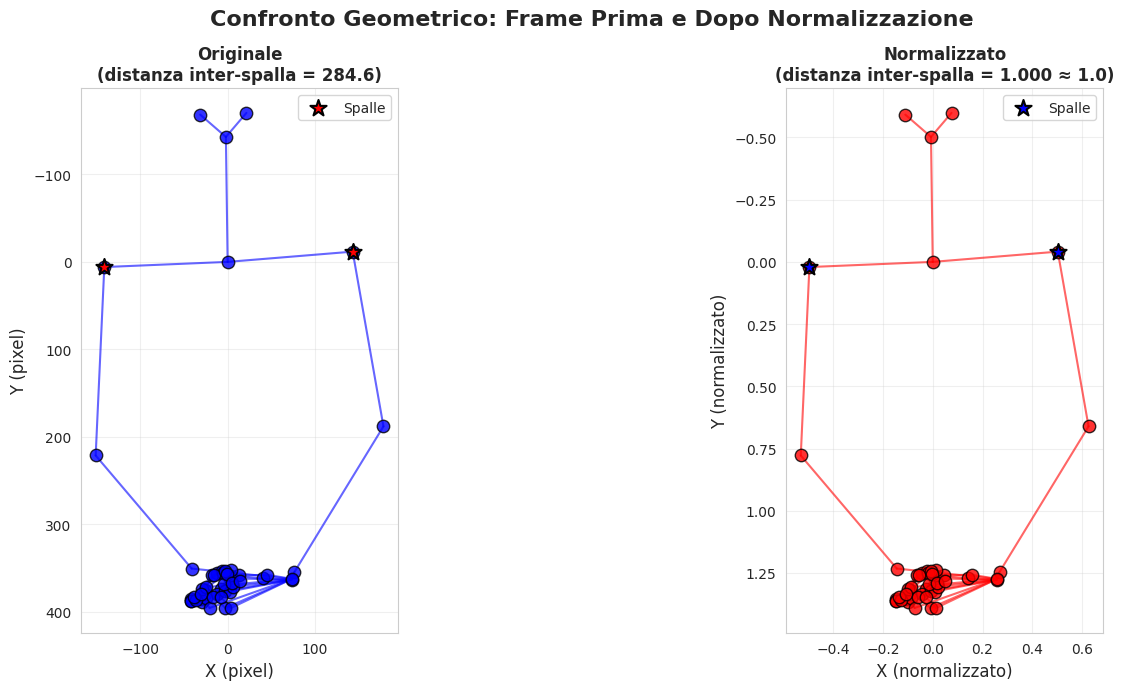


📏 CONFRONTO LUNGHEZZE OSSEE DEL FRAME:

RShoulder:
  Originale:    141.19 pixel
  Normalizzato: 0.4960
  Rapporto:     0.0035 (≈ 1/284.6)

RElbow:
  Originale:    215.75 pixel
  Normalizzato: 0.7580
  Rapporto:     0.0035 (≈ 1/284.6)

RWrist:
  Originale:    169.68 pixel
  Normalizzato: 0.5961
  Rapporto:     0.0035 (≈ 1/284.6)

LElbow:
  Originale:    202.96 pixel
  Normalizzato: 0.7131
  Rapporto:     0.0035 (≈ 1/284.6)

LWrist:
  Originale:    195.16 pixel
  Normalizzato: 0.6856
  Rapporto:     0.0035 (≈ 1/284.6)


In [17]:
# Carica un dataset di esempio e prendi un frame
sample_idx = np.random.choice(len(intervals))
clips = load_multiple_samples(speaker=speaker, interval_ids=intervals[sample_idx:sample_idx+1])

skeleton_poses = []
for clip in clips:
    pose = clip['pose']
    pose[:, 0] = [0.0, 0.0]  # centra il collo
    skeleton_poses.append(pose)

skeleton_poses = np.concatenate(skeleton_poses, axis=0)

# Prendi un frame a metà della sequenza
frame_idx = len(skeleton_poses) // 2
frame_orig = skeleton_poses[frame_idx]  # (J, 2)
frame_norm = SkeletonPATS.normalize_skeleton(frame_orig, scale=1.0)

# Calcola distanza inter-spalla
shoulder_dist_orig = np.linalg.norm(frame_orig[4] - frame_orig[1])
shoulder_dist_norm = np.linalg.norm(frame_norm[4] - frame_norm[1])

print(f"Frame selezionato: {frame_idx} del dataset {sample_idx}")
print(f"Distanza inter-spalla originale: {shoulder_dist_orig:.2f} pixel")
print(f"Distanza inter-spalla normalizzata: {shoulder_dist_norm:.2f} (target = 1.0)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Confronto Geometrico: Frame Prima e Dopo Normalizzazione', fontsize=16, fontweight='bold')

parents = SkeletonPATS.parents()
joint_names = SkeletonPATS.joint_names()

# Plot frame originale
ax = axes[0]
for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([frame_orig[j, 0], frame_orig[parent_idx, 0]],
               [frame_orig[j, 1], frame_orig[parent_idx, 1]],
               'b-', linewidth=1.5, alpha=0.6)

ax.scatter(frame_orig[:, 0], frame_orig[:, 1], c='blue', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

# Evidenzia spalle
ax.scatter([frame_orig[1, 0], frame_orig[4, 0]], 
          [frame_orig[1, 1], frame_orig[4, 1]], 
          c='red', s=150, marker='*', edgecolors='black', linewidth=1.5, 
          zorder=10, label='Spalle')

ax.set_xlabel('X (pixel)', fontsize=12)
ax.set_ylabel('Y (pixel)', fontsize=12)
ax.set_title(f'Originale\n(distanza inter-spalla = {shoulder_dist_orig:.1f})', fontweight='bold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()

# Plot frame normalizzato
ax = axes[1]
for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([frame_norm[j, 0], frame_norm[parent_idx, 0]],
               [frame_norm[j, 1], frame_norm[parent_idx, 1]],
               'r-', linewidth=1.5, alpha=0.6)

ax.scatter(frame_norm[:, 0], frame_norm[:, 1], c='red', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

# Evidenzia spalle
ax.scatter([frame_norm[1, 0], frame_norm[4, 0]], 
          [frame_norm[1, 1], frame_norm[4, 1]], 
          c='blue', s=150, marker='*', edgecolors='black', linewidth=1.5, 
          zorder=10, label='Spalle')

ax.set_xlabel('X (normalizzato)', fontsize=12)
ax.set_ylabel('Y (normalizzato)', fontsize=12)
ax.set_title(f'Normalizzato\n(distanza inter-spalla = {shoulder_dist_norm:.3f} ≈ 1.0)', fontweight='bold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Calcola e mostra alcune lunghezze ossee specifiche
bones_to_check = [
    (1, 'RShoulder'),
    (2, 'RElbow'),
    (3, 'RWrist'),
    (5, 'LElbow'),
    (6, 'LWrist')
]

print("\n📏 CONFRONTO LUNGHEZZE OSSEE DEL FRAME:")
print("="*60)
bone_lengths_orig = SkeletonPATS.compute_bone_lengths(frame_orig)
bone_lengths_norm = SkeletonPATS.compute_bone_lengths(frame_norm)

for joint_idx, joint_name in bones_to_check:
    orig_len = bone_lengths_orig[joint_idx]
    norm_len = bone_lengths_norm[joint_idx]
    ratio = norm_len / orig_len if orig_len > 0 else 0
    
    print(f"\n{joint_name}:")
    print(f"  Originale:    {orig_len:.2f} pixel")
    print(f"  Normalizzato: {norm_len:.4f}")
    print(f"  Rapporto:     {ratio:.4f} (≈ 1/{shoulder_dist_orig:.1f})")